In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

DATA_PATH = Path("/Users/ritvik/src/umd_classes1/class_project/MSML610/Fall2025/Projects/UmdTask68_Fall2025_auto_sklearn_House_Price_Estimation_in_India/data/raw/india_housing_prices.csv")

In [8]:
df = pd.read_csv(DATA_PATH)
df = df.replace(r"^\s*$", pd.NA, regex=True)

display(df.head())
df.info()
df.describe(include="all").T

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,250000.0,NaN,NaN,NaN,125000.5,72168.927986,1.0,62500.75,125000.5,187500.25,250000.0
State,250000,20,Odisha,12681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,250000,42,Coimbatore,6461,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Locality,250000,500,Locality_296,567,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Property_Type,250000,3,Villa,83744,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BHK,250000.0,NaN,NaN,NaN,2.999396,1.415521,1.0,2.0,3.0,4.0,5.0
Size_in_SqFt,250000.0,NaN,NaN,NaN,2749.813216,1300.606954,500.0,1623.0,2747.0,3874.0,5000.0
Price_in_Lakhs,250000.0,NaN,NaN,NaN,254.586854,141.349921,10.0,132.55,253.87,376.88,500.0
Price_per_SqFt,250000.0,NaN,NaN,NaN,0.130597,0.130747,0.0,0.05,0.09,0.16,0.99
Year_Built,250000.0,NaN,NaN,NaN,2006.520012,9.808575,1990.0,1998.0,2007.0,2015.0,2023.0


TARGET DISTRIBUTION AND NUMERIC SUMMARY
- Price distribution is faily broad without any sharp peaks
- Numeric stats lis means, stds, quartiles

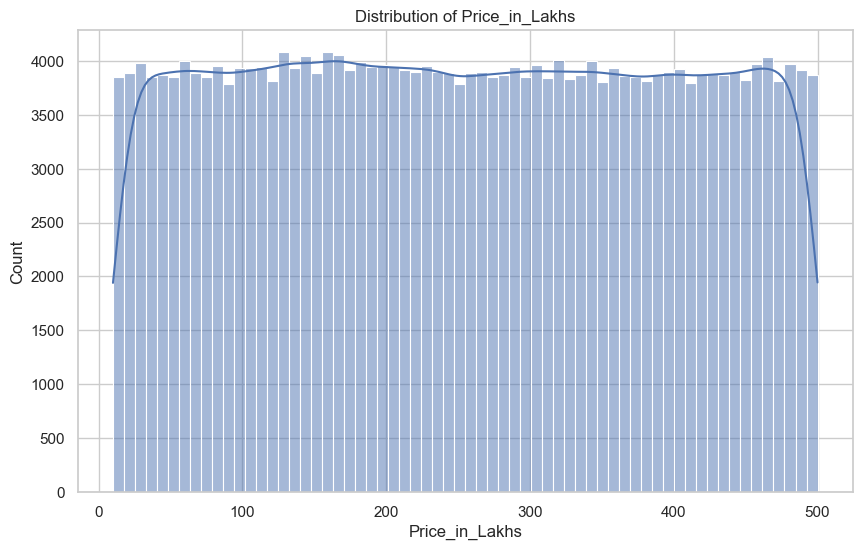

,count,mean,std,min,25%,50%,75%,max
BHK,250000.0,2.999396,1.415521,1.0,2.00,3.00,4.00,5.00
Size_in_SqFt,250000.0,2749.813216,1300.606954,500.0,1623.00,2747.00,3874.00,5000.00
Price_per_SqFt,250000.0,0.130597,0.130747,0.0,0.05,0.09,0.16,0.99
Year_Built,250000.0,2006.520012,9.808575,1990.0,1998.00,2007.00,2015.00,2023.00
Floor_No,250000.0,14.966800,8.948047,0.0,7.00,15.00,23.00,30.00
Total_Floors,250000.0,15.503004,8.671618,1.0,8.00,15.00,23.00,30.00
Age_of_Property,250000.0,18.479988,9.808575,2.0,10.00,18.00,27.00,35.00
Nearby_Schools,250000.0,5.499860,2.878639,1.0,3.00,5.00,8.00,10.00
Nearby_Hospitals,250000.0,5.498016,2.871860,1.0,3.00,5.00,8.00,10.00


In [4]:
target = "Price_in_Lakhs"
numeric_cols = [
    "BHK", "Size_in_SqFt", "Price_per_SqFt", "Year_Built",
    "Floor_No", "Total_Floors", "Age_of_Property",
    "Nearby_Schools", "Nearby_Hospitals"
]

sns.histplot(df[target], kde=True)
plt.title("Distribution of Price_in_Lakhs")
plt.show()

df[numeric_cols].describe().T

MISSINGNESS

- The missing percentage table triggers a pandas warning because every column has 0% missing (division by zero in the style gradient)
- The heatmap shows an empty grid (again meaning no missing values)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/io/formats/style.py:4040: RuntimeWarning: invalid value encountered in scalar divide
  end = (x - left) / (right - left)


,missing_fraction
ID,0.000000
State,0.000000
City,0.000000
Locality,0.000000
Property_Type,0.000000
BHK,0.000000
Size_in_SqFt,0.000000
Price_in_Lakhs,0.000000
Price_per_SqFt,0.000000
Year_Built,0.000000


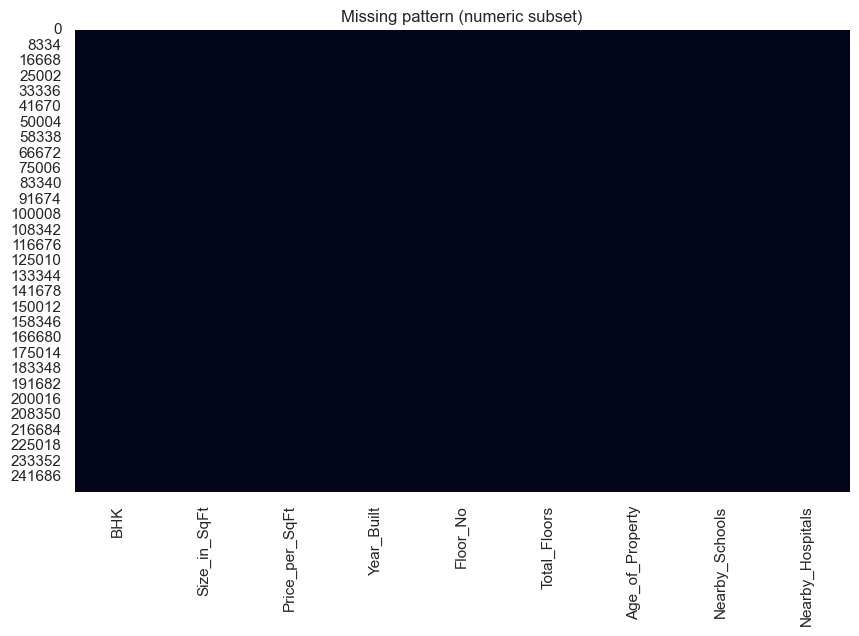

In [5]:
missing_pct = df.isna().mean().sort_values(ascending=False)
display(missing_pct.to_frame("missing_fraction").style.bar(color="lightcoral"))

sns.heatmap(df[numeric_cols].isna(), cbar=False)
plt.title("Missing pattern (numeric subset)")
plt.show()

CATAGORICAL COUNTS
- Printing top 10 frequency counts per column
- Nothing crazy here, all values are pretty similar here within each category

In [6]:
categorical_cols = [c for c in df.columns if df[c].dtype == "object" and c not in ("Amenities", target)]
for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False).head(10))


--- State ---


State
Odisha           12681
Tamil Nadu       12629
West Bengal      12622
Gujarat          12578
Delhi            12552
Telangana        12539
Maharashtra      12533
Punjab           12516
Uttar Pradesh    12508
Uttarakhand      12501
Name: count, dtype: int64


--- City ---


City
Coimbatore     6461
Ahmedabad      6411
Silchar        6404
Durgapur       6387
Cuttack        6358
Vijayawada     6344
Jamshedpur     6335
Bhubaneswar    6323
New Delhi      6306
Kochi          6305
Name: count, dtype: int64


--- Locality ---


...

Facing
West     62757
North    62637
South    62337
East     62269
Name: count, dtype: int64


--- Owner_Type ---


Owner_Type
Broker     83479
Owner      83268
Builder    83253
Name: count, dtype: int64


--- Availability_Status ---


Availability_Status
Under_Construction    125035
Ready_to_Move         124965
Name: count, dtype: int64

CORRELATION
- Heatmap colours are very muted and the numeric annotations hover near 0 hsowing weak linear relationships
- The pairplot scatterclouds look very uniform matching that correlation matrix
- The dataset appears to be synthetically generated with loosely coupled features
- Price_in_Lakhs, Size_in_SqFt, BHK, and Price_per_SqFt look only weakly tied so linear correlation is low

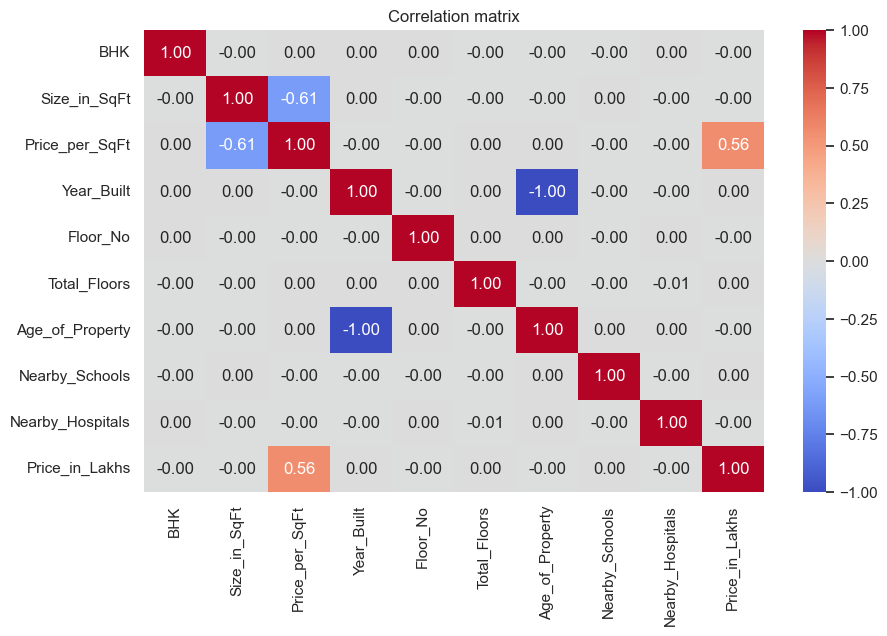

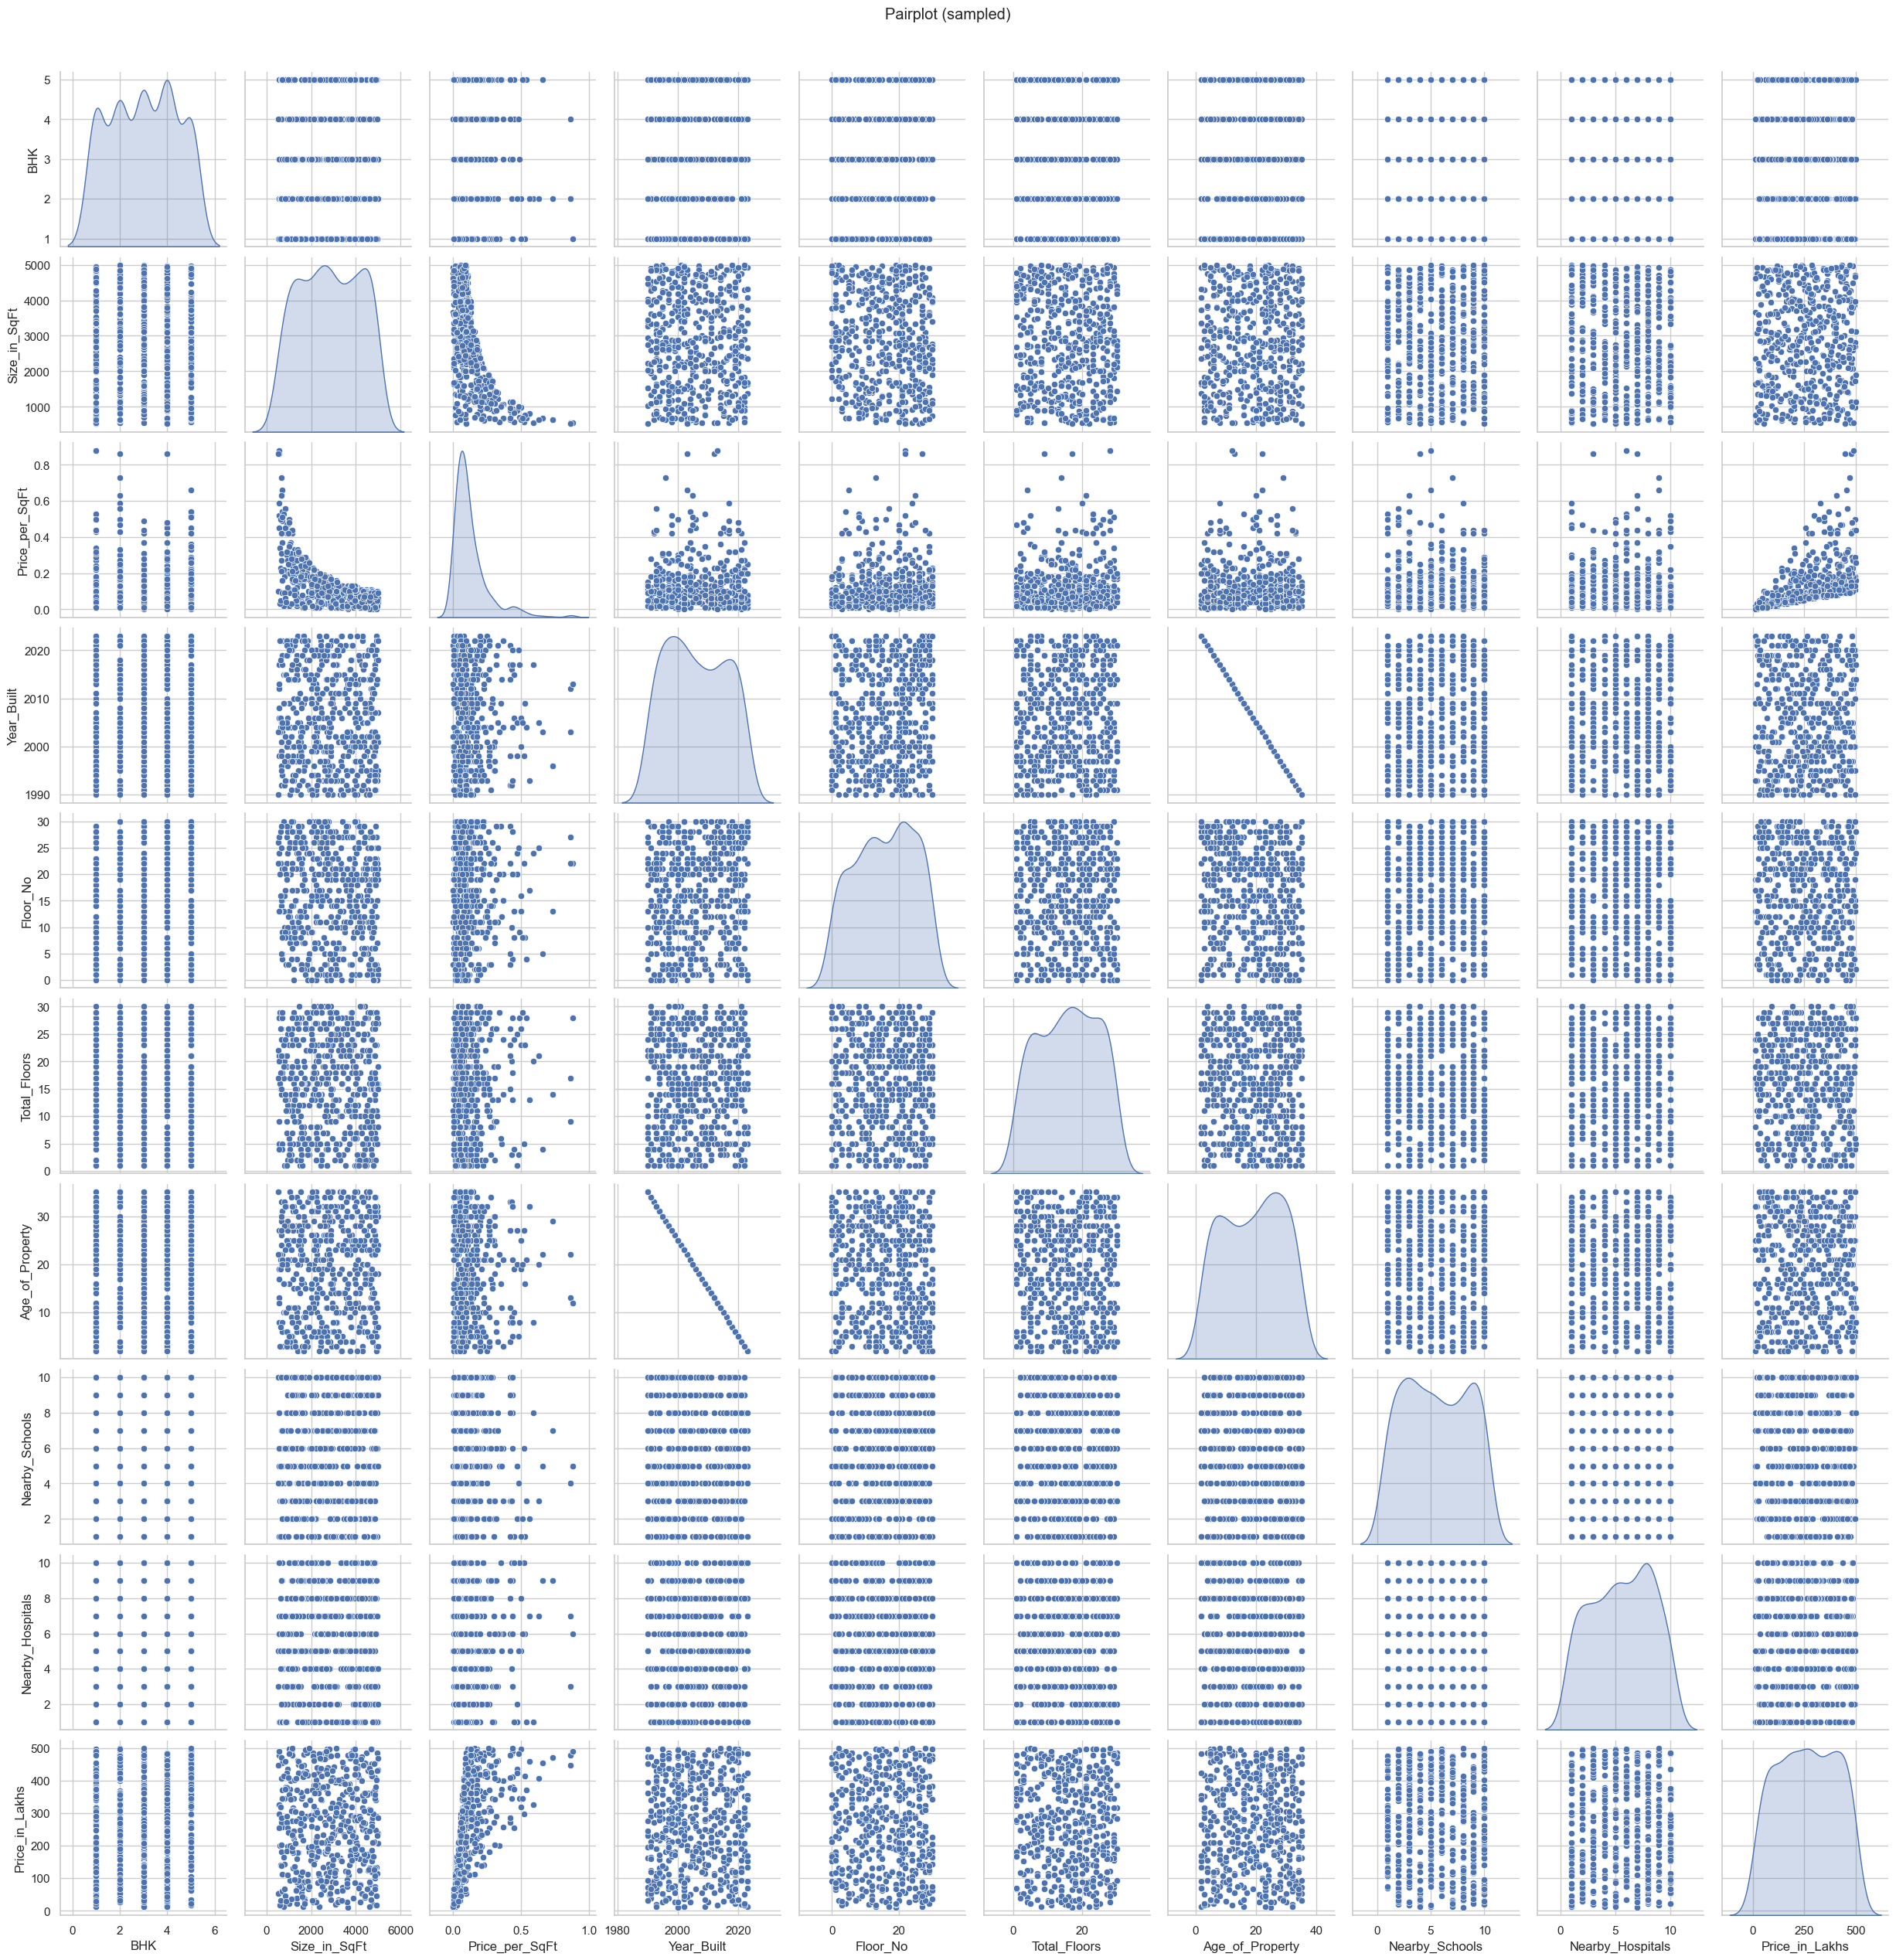

In [7]:
corr = df[numeric_cols + [target]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

sns.pairplot(df[numeric_cols + [target]].sample(500, random_state=42), diag_kind="kde")
plt.suptitle("Pairplot (sampled)", y=1.02)
plt.show()

MEDIAN PRICE PIVOT
- Displays median price in lakhs 

Furnished_Status,Furnished,Semi-furnished,Unfurnished
Property_Type,,,
Apartment,252.530,254.42,254.840
Independent House,255.410,254.96,254.745
Villa,252.765,251.81,253.090


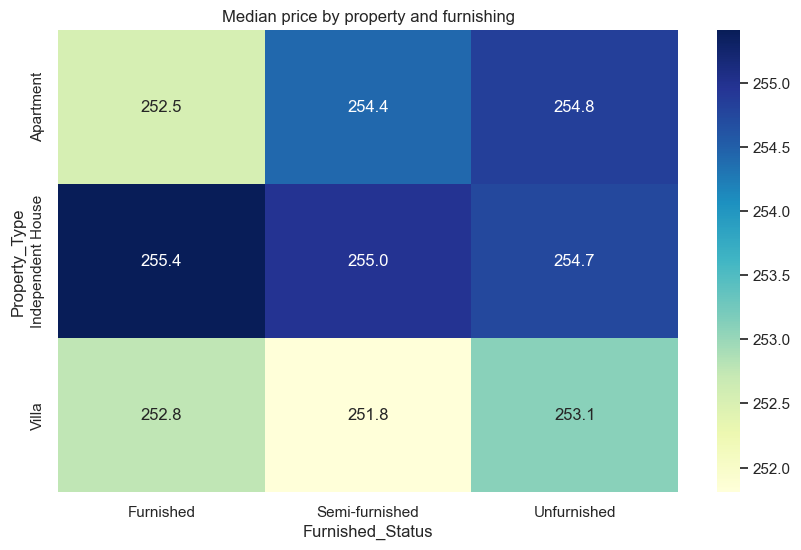

In [8]:
pivot = (
    df.pivot_table(
        values=target,
        index="Property_Type",
        columns="Furnished_Status",
        aggfunc="median"
    )
)
display(pivot)
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Median price by property and furnishing")
plt.show()

In [ ]:
print("Rows:", len(df))
print("Distinct states:", df["State"].nunique())
print("Distinct cities:", df["City"].nunique())

Rows: 250000
Distinct states: 20
Distinct cities: 42
